In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], errors="ignore", inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

dataset = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")


In [3]:
dataset["hour_sin"] = dataset["timestamp"].apply(lambda x: np.sin(2 * np.pi * x.hour / 24.0))
dataset["hour_cos"] = dataset["timestamp"].apply(lambda x: np.cos(2 * np.pi * x.hour / 24.0))

In [4]:
dataset.drop(columns=["time_x", "time_y"], inplace=True)

In [5]:
TARGET_COL = "pm2_5 (μg/m³)"


df = dataset.copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 
FEATURE_COLS = list(df.columns)
N_FEATURES = len(FEATURE_COLS)
TARGET_SCALER_IDX = FEATURE_COLS.index(TARGET_COL)

INPUT_WINDOW = 24 *3
OUTPUT_WINDOW = 24
BATCH_SIZE = 64

train_raw = df.loc[:"2024-12-31 23:00:00", FEATURE_COLS].copy()
test_raw = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00", FEATURE_COLS].copy()

scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw), columns=FEATURE_COLS, index=train_raw.index)
test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=FEATURE_COLS, index=test_raw.index)


def create_clock_anchored_sequences(df_scaled, feature_cols, target_col, input_w, output_w):
    X, Y = [], []
    feature_matrix = df_scaled[feature_cols].values
    target_vector = df_scaled[target_col].values
    
    for i in range(len(df_scaled) - input_w - output_w + 1):
        X.append(feature_matrix[i : i + input_w, :])
        Y.append(target_vector[i + input_w : i + input_w + output_w])
        
    return np.array(X), np.array(Y)

X_train, y_train = create_clock_anchored_sequences(train_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_clock_anchored_sequences(test_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)

In [6]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [7]:
import torch
import torch.nn as nn

class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super(TransformerLSTMModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        x = self.input_projection(src)
        x = x + self.pos_encoder[:, :src.size(1), :]
        x = self.dropout(x)
        transformer_out = self.transformer_encoder(x)
        lstm_out, (hn, cn) = self.lstm(transformer_out)
        out = lstm_out[:, -1, :]
        predictions = self.fc(self.dropout(out))
        return predictions

In [8]:
from pytorch_lightning.callbacks import Callback

class SimpleLossTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(train_loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

loss_tracker = SimpleLossTracker()

In [9]:
def inverse_transform_target(scaled_data, scaler, target_idx, n_features):
    flat_data = scaled_data.flatten()
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, target_idx] = flat_data
    unscaled_dummy = scaler.inverse_transform(dummy)
    return unscaled_dummy[:, target_idx].reshape(scaled_data.shape)

In [10]:
from sklearn.metrics import r2_score as sk_r2

def _run_inference(model, X_np, scaler, target_idx, n_features, device, batch_size=512):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32)
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            preds.append(model(X_t[i:i+batch_size].to(device)).cpu().numpy())
    p = inverse_transform_target(np.vstack(preds), scaler, target_idx, n_features)
    return p


def permutation_importance_timeseries(
    model, X_np, y_np_inv, feature_cols, scaler,
    target_idx, n_features, device,
    n_repeats=10, batch_size=512, seed=42,
):
    rng = np.random.default_rng(seed)
    n_samples = X_np.shape[0]
    y_flat = y_np_inv.flatten()

    base_pred = _run_inference(model, X_np, scaler, target_idx, n_features, device, batch_size)
    baseline_mae = mean_absolute_error(y_flat, base_pred.flatten())
    baseline_r2  = sk_r2(y_flat, base_pred.flatten())
    print(f"Baseline  MAE={baseline_mae:.4f} μg/m³  R²={baseline_r2:.4f}")

    importances = {}
    for feat_idx, feat_name in enumerate(feature_cols):
        d_mae, d_r2 = [], []
        for _ in range(n_repeats):
            X_p = X_np.copy()
            idx = rng.permutation(n_samples)
            X_p[:, :, feat_idx] = X_p[idx, :, feat_idx]
            p = _run_inference(model, X_p, scaler, target_idx, n_features, device, batch_size)
            pf = p.flatten()
            d_mae.append(mean_absolute_error(y_flat, pf) - baseline_mae)
            d_r2.append(baseline_r2 - sk_r2(y_flat, pf))
        importances[feat_name] = {
            'mae_mean': float(np.mean(d_mae)), 'mae_std': float(np.std(d_mae)),
            'r2_mean':  float(np.mean(d_r2)),  'r2_std':  float(np.std(d_r2)),
        }
        print(f"  {feat_name:40s}  ΔMAE={importances[feat_name]['mae_mean']:+.4f}±{importances[feat_name]['mae_std']:.4f}  "
              f"ΔR²={importances[feat_name]['r2_mean']:+.4f}±{importances[feat_name]['r2_std']:.4f}")

    return baseline_mae, baseline_r2, importances


In [11]:
import copy
import numpy as np
import pandas as pd
import torch

def backward_feature_elimination(
    model_class, 
    model_kwargs, 
    df_train, 
    df_test, 
    initial_features, 
    target_col, 
    input_w, 
    output_w, 
    batch_size=64, 
    device="cuda",
    epochs=10, # Adjust training epochs per iteration
    lr=1e-3
):
    current_features = list(initial_features)
    best_score = float("inf")
    best_feature_set = list(current_features)
    
    iteration = 1
    
    while len(current_features) > 1:
        print(f"\n--- Iteration {iteration} | Active Features: {len(current_features)} ---")
        
        # 1. Scale data based on current feature subset
        target_idx = current_features.index(target_col)
        n_features = len(current_features)
        
        scaler = MinMaxScaler()
        train_scaled = pd.DataFrame(scaler.fit_transform(df_train[current_features]), columns=current_features, index=df_train.index)
        test_scaled = pd.DataFrame(scaler.transform(df_test[current_features]), columns=current_features, index=df_test.index)
        
        # 2. Build datasets
        X_tr, y_tr = create_clock_anchored_sequences(train_scaled, current_features, target_col, input_w, output_w)
        X_te, y_te = create_clock_anchored_sequences(test_scaled, current_features, target_col, input_w, output_w)
        
        train_loader = DataLoader(
            TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32)),
            batch_size=batch_size, shuffle=True
        )
        
        # 3. Instantiate and train a fresh model
        kwargs = copy.deepcopy(model_kwargs)
        kwargs["input_dim"] = n_features
        model = model_class(**kwargs).to(device)
        
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        criterion = nn.MSELoss()
        
        model.train()
        for epoch in range(epochs):
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()
                
        # 4. Evaluate baseline & permutation importance on test set
        y_test_inv = inverse_transform_target(y_te, scaler, target_idx, n_features)
        baseline_mae, baseline_r2, importances = permutation_importance_timeseries(
            model=model,
            X_np=X_te,
            y_np_inv=y_test_inv,
            feature_cols=current_features,
            scaler=scaler,
            target_idx=target_idx,
            n_features=n_features,
            device=device,
            n_repeats=5,
            batch_size=batch_size
        )
        
        print(f"Iteration {iteration} Model MAE: {baseline_mae:.4f}")
        
        # Track overall best model configuration
        if baseline_mae < best_score:
            best_score = baseline_mae
            best_feature_set = list(current_features)
            

        candidate_drops = [
            (feat, metrics["mae_mean"]) 
            for feat, metrics in importances.items() 
            if feat != target_col
        ]
        
        if not candidate_drops:
            break
            
        candidate_drops.sort(key=lambda x: x[1])
        worst_feature, worst_impact = candidate_drops[0]
        
        # Stopping condition: if all remaining non-target features strictly improve the model (ΔMAE > threshold), stop
        if worst_impact > 0.1:
            print(f"Stopping: All remaining features contribute positively to performance.")
            break
            
        print(f"Removing weakest feature: '{worst_feature}' (ΔMAE impact: {worst_impact:+.4f})")
        current_features.remove(worst_feature)
        iteration += 1

    print("\n==========================================")
    print(f"Optimal Feature Subset ({len(best_feature_set)} features):")
    print(best_feature_set)
    print(f"Best MAE Achieved: {best_score:.4f}")
    print("==========================================")
    
    return best_feature_set

In [12]:
model_config = {
    "d_model": 64,
    "nhead": 4,
    "num_transformer_layers": 1,
    "hidden_dim": 256,
    "num_lstm_layers": 3,
    "output_dim": OUTPUT_WINDOW,
    "seq_len": INPUT_WINDOW,
    "dropout": 0.45
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

optimal_features = backward_feature_elimination(
    model_class=TransformerLSTMModel,
    model_kwargs=model_config,
    df_train=train_raw,
    df_test=test_raw,
    initial_features=FEATURE_COLS,
    target_col=TARGET_COL,
    input_w=INPUT_WINDOW,
    output_w=OUTPUT_WINDOW,
    batch_size=BATCH_SIZE,
    device=DEVICE,
    epochs=50,
    lr=1e-3
)


--- Iteration 1 | Active Features: 25 ---
Baseline  MAE=4.5024 μg/m³  R²=0.1446
  temperature_2m (°C)                       ΔMAE=+0.0334±0.0064  ΔR²=+0.0059±0.0014
  relative_humidity_2m (%)                  ΔMAE=+0.0267±0.0180  ΔR²=-0.0054±0.0054
  dew_point_2m (°C)                         ΔMAE=-0.0011±0.0120  ΔR²=-0.0029±0.0030
  apparent_temperature (°C)                 ΔMAE=+0.0050±0.0050  ΔR²=-0.0059±0.0014
  precipitation (mm)                        ΔMAE=+0.0366±0.0168  ΔR²=+0.0116±0.0055
  rain (mm)                                 ΔMAE=+0.0308±0.0058  ΔR²=+0.0101±0.0030
  weather_code (wmo code)                   ΔMAE=+0.0688±0.0251  ΔR²=+0.0291±0.0058
  wind_speed_10m (km/h)                     ΔMAE=+0.1611±0.0360  ΔR²=+0.0360±0.0073
  wind_speed_100m (km/h)                    ΔMAE=+0.2826±0.0522  ΔR²=+0.0820±0.0202
  wind_direction_10m (°)                    ΔMAE=-0.0271±0.0129  ΔR²=-0.0024±0.0042
  wind_direction_100m (°)                   ΔMAE=+0.0996±0.0522  ΔR²=+0.0298±0.

In [13]:
FEATURE_COLS = optimal_features
TARGET_COL = "pm2_5 (μg/m³)"
N_FEATURES = len(FEATURE_COLS)
TARGET_SCALER_IDX = FEATURE_COLS.index(TARGET_COL)


df = dataset[FEATURE_COLS + ["timestamp"]].copy()
df.set_index("timestamp", inplace=True)
df = df.sort_index().asfreq("h") 

INPUT_WINDOW = 24 * 3
OUTPUT_WINDOW = 24
BATCH_SIZE = 64

train_raw = df.loc[:"2024-12-31 23:00:00", FEATURE_COLS].copy()
test_raw = df.loc["2025-01-01 00:00:00":"2025-12-31 23:00:00", FEATURE_COLS].copy()

scaler = MinMaxScaler()
train_scaled = pd.DataFrame(scaler.fit_transform(train_raw), columns=FEATURE_COLS, index=train_raw.index)
test_scaled = pd.DataFrame(scaler.transform(test_raw), columns=FEATURE_COLS, index=test_raw.index)


def create_clock_anchored_sequences(df_scaled, feature_cols, target_col, input_w, output_w):
    X, Y = [], []
    feature_matrix = df_scaled[feature_cols].values
    target_vector = df_scaled[target_col].values
    
    for i in range(len(df_scaled) - input_w - output_w + 1):
        X.append(feature_matrix[i : i + input_w, :])
        Y.append(target_vector[i + input_w : i + input_w + output_w])
        
    return np.array(X), np.array(Y)

X_train, y_train = create_clock_anchored_sequences(train_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)
X_test, y_test = create_clock_anchored_sequences(test_scaled, FEATURE_COLS, TARGET_COL, INPUT_WINDOW, OUTPUT_WINDOW)

In [14]:
train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
import torch
import torch.nn as nn

class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super(TransformerLSTMModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src):
        x = self.input_projection(src)
        x = x + self.pos_encoder[:, :src.size(1), :]
        x = self.dropout(x)
        transformer_out = self.transformer_encoder(x)
        lstm_out, (hn, cn) = self.lstm(transformer_out)
        out = lstm_out[:, -1, :]
        predictions = self.fc(self.dropout(out))
        return predictions

In [16]:
import optuna
import torch.optim as optim
import torch.nn as nn
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def objective(trial):
    # 1. Define the Hyperparameter Search Space
    d_model = trial.suggest_categorical("d_model", [32, 48, 64, 128])
    nhead = trial.suggest_categorical("nhead", [2, 4, 8, 16])
    
    if d_model % nhead != 0:
        raise optuna.exceptions.TrialPruned()
    num_transformer_layers = trial.suggest_int("num_transformer_layers", 1, 6)
    hidden_dim = trial.suggest_categorical("hidden_dim", [16, 32, 64, 128, 256])
    num_lstm_layers = trial.suggest_int("num_lstm_layers", 1, 4)
    dropout = trial.suggest_float("dropout", 0.0, 0.6)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    
    # 2. Instantiate Model
    trial_model = TransformerLSTMModel(
        input_dim=N_FEATURES, 
        seq_len=INPUT_WINDOW, 
        d_model=d_model, 
        nhead=nhead, 
        num_transformer_layers=num_transformer_layers, 
        hidden_dim=hidden_dim,  
        num_lstm_layers=num_lstm_layers, 
        dropout=dropout, 
        output_dim=OUTPUT_WINDOW
    ).to(DEVICE)
    
    trial_optimizer = optim.Adam(trial_model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    epochs = 50
    
    total_train_loss = 0.0
    total_val_loss = 0.0
    
    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        trial_model.train()
        epoch_train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            trial_optimizer.zero_grad(set_to_none=True)
            predictions = trial_model(batch_x)
            loss = criterion(predictions, batch_y)
            loss.backward()
            
            nn.utils.clip_grad_norm_(trial_model.parameters(), max_norm=1.0)
            trial_optimizer.step()
            
            epoch_train_loss += loss.item() * batch_x.size(0)
            
        total_train_loss = epoch_train_loss / len(train_loader.dataset)
            
        # --- VALIDATION PHASE ---
        trial_model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x = batch_x.to(DEVICE, non_blocking=True)
                batch_y = batch_y.to(DEVICE, non_blocking=True)
                val_predictions = trial_model(batch_x)
                val_loss = criterion(val_predictions, batch_y)
                epoch_val_loss += val_loss.item() * batch_x.size(0)
                
        total_val_loss = epoch_val_loss / len(test_loader.dataset)
        
        trial.report(total_val_loss, epoch)
        
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    generalization_gap = abs(total_val_loss - total_train_loss)
    overfitting_penalty = 0.25 * generalization_gap
    optimization_metric = total_val_loss + overfitting_penalty

    return optimization_metric

# Initialize Study with the Pruner
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(),
    pruner=optuna.pruners.SuccessiveHalvingPruner(
        min_resource=350,
        reduction_factor=2
    )
)

study.optimize(objective, n_trials=40)

print("\n--- Optimization Complete ---")
print("Best Trial Value (Metric + Penalty):", study.best_trial.value)
print("Best Hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

/data/ll2531/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-27 14:17:34,582] A new study created in memory with name: no-name-3540e14f-290d-457d-bfdd-3e25184e86ed
[I 2026-07-27 14:21:23,407] Trial 0 finished with value: 0.0040688140414141954 and parameters: {'d_model': 32, 'nhead': 16, 'num_transformer_layers': 1, 'hidden_dim': 128, 'num_lstm_layers': 4, 'dropout': 0.4247016414207421, 'lr': 4.7145672615890966e-05}. Best is trial 0 with value: 0.0040688140414141954.
[I 2026-07-27 14:26:39,320] Trial 1 finished with value: 0.004529721508203107 and parameters: {'d_model': 32, 'nhead': 4, 'num_transformer_layers': 3, 'hidden_dim': 128, 'num_lstm_layers': 3, 'dropout': 0.42849583453707746, 'lr': 0.00034680986682196886}. Best is trial 0 with value: 0.0040688140414141954.
[I 2026-07-27 14:33:1


--- Optimization Complete ---
Best Trial Value (Metric + Penalty): 0.0022300351470979514
Best Hyperparameters:
  d_model: 48
  nhead: 8
  num_transformer_layers: 5
  hidden_dim: 32
  num_lstm_layers: 1
  dropout: 0.11778274781247755
  lr: 1.4564682803769691e-05


In [17]:
from pytorch_lightning.callbacks import Callback

class SimpleLossTracker(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        train_loss = trainer.callback_metrics.get("train_loss")
        if train_loss is not None:
            self.train_losses.append(train_loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        val_loss = trainer.callback_metrics.get("val_loss")
        if val_loss is not None:
            self.val_losses.append(val_loss.item())

loss_tracker = SimpleLossTracker()

In [18]:
def inverse_transform_target(scaled_data, scaler, target_idx, n_features):
    flat_data = scaled_data.flatten()
    dummy = np.zeros((len(flat_data), n_features))
    dummy[:, target_idx] = flat_data
    unscaled_dummy = scaler.inverse_transform(dummy)
    return unscaled_dummy[:, target_idx].reshape(scaled_data.shape)

In [19]:
best_params = study.best_trial.params
best_params["num_transformer_layers"] = 1

In [20]:
import torch.optim as optim
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score as sklearn_r2


print("\n--- Best Hyperparameters Found ---")
for key, value in best_params.items():
    print(f"  {key}: {value}")

final_model = TransformerLSTMModel(
    input_dim=N_FEATURES, 
    seq_len=INPUT_WINDOW, 
    d_model=best_params["d_model"], 
    nhead=best_params["nhead"], 
    num_transformer_layers=best_params["num_transformer_layers"], 
    hidden_dim=best_params["hidden_dim"],  
    num_lstm_layers=best_params["num_lstm_layers"], 
    dropout=best_params["dropout"], 
    output_dim=OUTPUT_WINDOW
).to(DEVICE)

final_optimizer = optim.Adam(final_model.parameters(), lr=best_params["lr"])
criterion = nn.MSELoss()

hist_train = []
hist_val = []
FINAL_EPOCHS = 60

print(f"\nTraining final optimized model for {FINAL_EPOCHS} epochs...")
for epoch in range(FINAL_EPOCHS):
    final_model.train()
    epoch_train_loss = 0.0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(DEVICE, non_blocking=True)
        batch_y = batch_y.to(DEVICE, non_blocking=True)

        final_optimizer.zero_grad(set_to_none=True)
        predictions = final_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        
        nn.utils.clip_grad_norm_(final_model.parameters(), max_norm=1.0)
        final_optimizer.step()
        
        epoch_train_loss += loss.item() * batch_x.size(0)

    total_train_loss = epoch_train_loss / len(train_loader.dataset)
    hist_train.append(total_train_loss)

    final_model.eval()
    epoch_val_loss = 0.0
    
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(DEVICE, non_blocking=True)
            batch_y = batch_y.to(DEVICE, non_blocking=True)
            
            val_predictions = final_model(batch_x)
            val_loss = criterion(val_predictions, batch_y)
            
            epoch_val_loss += val_loss.item() * batch_x.size(0)
            
    total_val_loss = epoch_val_loss / len(test_loader.dataset)
    hist_val.append(total_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | Train Loss (MSE): {total_train_loss:.6f} | Val Loss (MSE): {total_val_loss:.6f}")



--- Best Hyperparameters Found ---
  d_model: 48
  nhead: 8
  num_transformer_layers: 1
  hidden_dim: 32
  num_lstm_layers: 1
  dropout: 0.11778274781247755
  lr: 1.4564682803769691e-05

Training final optimized model for 60 epochs...
Epoch 01/60 | Train Loss (MSE): 0.017102 | Val Loss (MSE): 0.006010
Epoch 10/60 | Train Loss (MSE): 0.003384 | Val Loss (MSE): 0.002601
Epoch 20/60 | Train Loss (MSE): 0.002950 | Val Loss (MSE): 0.002390
Epoch 30/60 | Train Loss (MSE): 0.002774 | Val Loss (MSE): 0.002354
Epoch 40/60 | Train Loss (MSE): 0.002657 | Val Loss (MSE): 0.002256
Epoch 50/60 | Train Loss (MSE): 0.002555 | Val Loss (MSE): 0.002271
Epoch 60/60 | Train Loss (MSE): 0.002483 | Val Loss (MSE): 0.002255


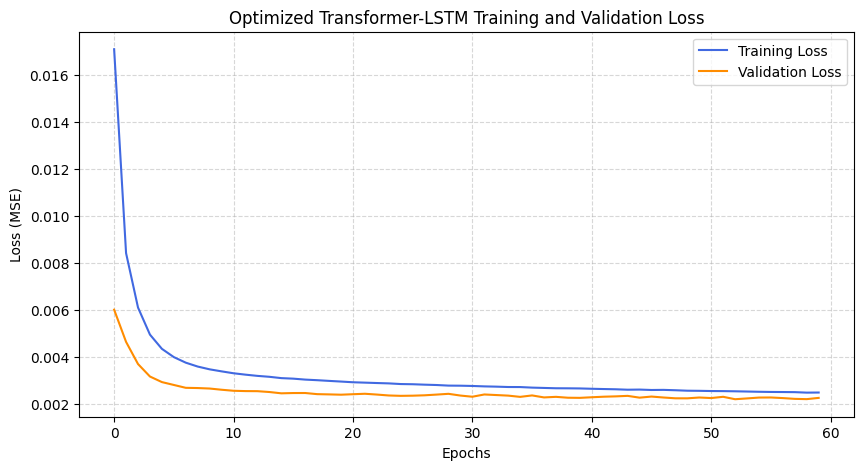

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(hist_train, label='Training Loss', color='royalblue')
plt.plot(hist_val, label='Validation Loss', color='darkorange')
plt.title('Optimized Transformer-LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

In [22]:
final_model.eval()
all_predictions = []
all_ground_truth = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(DEVICE)
        
        preds = final_model(batch_x).cpu().numpy()
        actuals = batch_y.numpy()
        
        all_predictions.append(preds)
        all_ground_truth.append(actuals)

all_predictions = np.vstack(all_predictions)
all_ground_truth = np.vstack(all_ground_truth)

true_predictions_all = inverse_transform_target(all_predictions, scaler, TARGET_SCALER_IDX, N_FEATURES)
true_ground_truth_all = inverse_transform_target(all_ground_truth, scaler, TARGET_SCALER_IDX, N_FEATURES)

global_mae = mean_absolute_error(true_ground_truth_all.flatten(), true_predictions_all.flatten())
global_rmse = np.sqrt(mean_squared_error(true_ground_truth_all.flatten(), true_predictions_all.flatten()))
global_r2 = sklearn_r2(true_ground_truth_all.flatten(), true_predictions_all.flatten())

ground_truth_mean = np.mean(true_ground_truth_all)
mae_percentage = (global_mae / ground_truth_mean)
rmse_percentage = (global_rmse / ground_truth_mean)

print(f"\n=== Final Transformer-LSTM Benchmark Results ===")
print(f"Global R² Score     : {global_r2:.4f}")
print(f"Global MAE          : {global_mae:.4f} μg/m³")
print(f"Global RMSE         : {global_rmse:.4f} μg/m³")
print(f"MAE% (Normalized)   : {mae_percentage:.2f}")
print(f"RMSE% (Normalized)  : {rmse_percentage:.2f}")


=== Final Transformer-LSTM Benchmark Results ===
Global R² Score     : 0.6190
Global MAE          : 2.4387 μg/m³
Global RMSE         : 3.5564 μg/m³
MAE% (Normalized)   : 0.32
RMSE% (Normalized)  : 0.47


In [23]:
import plotly.graph_objects as go

sample_indices = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600]
num_samples = len(sample_indices)

fig = go.Figure()
buttons = []

for idx, sample_idx in enumerate(sample_indices):
    # Pull directly from pre-computed, inverted arrays to avoid loop overhead
    true_actual = true_ground_truth_all[sample_idx]
    true_pred = true_predictions_all[sample_idx]
    
    start_timestamp_idx = INPUT_WINDOW + sample_idx
    window_timestamps = df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[
        start_timestamp_idx : start_timestamp_idx + OUTPUT_WINDOW
    ]
    time_labels = [str(t).split()[1][:5] for t in window_timestamps]
    date_str = str(window_timestamps[0]).split()[0]
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_actual,
        mode='lines+markers',
        name=f'Actual PM2.5 ({date_str})',
        line=dict(color='seagreen', width=3),
        visible=(idx == 0)
    ))
    
    fig.add_trace(go.Scatter(
        x=time_labels, y=true_pred,
        mode='lines+markers',
        name=f'Transformer-LSTM Forecast ({date_str})',
        line=dict(color='darkorange', width=2, dash='dash'),
        visible=(idx == 0)
    ))
    
    visibility_mask = [False] * (num_samples * 2)
    visibility_mask[idx * 2] = True
    visibility_mask[idx * 2 + 1] = True
    
    buttons.append(dict(
        label=f"Horizon: {date_str}",
        method="update",
        args=[
            {"visible": visibility_mask},
            {"title": f"<b>Transformer-LSTM Performance Horizon: {date_str}</b>"} 
        ]
    ))

initial_date_str = str(df.loc["2025-01-01 00:00:00":"2025-01-31 23:00:00"].index[INPUT_WINDOW]).split()[0]

fig.update_layout(
    title=dict(
        text=f'<b>Transformer-LSTM Performance Horizon: {initial_date_str}</b>',
        x=0.5,
        font=dict(size=16)
    ),
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            pad={"r": 10, "t": 10},
            showactive=True,
            x=0.0,
            xanchor="left",
            y=1.15,
            yanchor="top"
        )
    ],
    xaxis=dict(title='Hour of Day (24h Forecast Horizon)', showgrid=True, gridcolor='lightgray'),
    yaxis=dict(title='PM2.5 Concentration (μg/m³)', showgrid=True, gridcolor='lightgray'),
    template='plotly_white',
    hovermode='x unified',
    height=550,
    width=900,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="right",
        x=1
    )
)

fig.show()

In [24]:
with open("./models_saved/4.6multivariate.pkl", "wb") as file:
    pickle.dump(final_model, file)